In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Statement.pdf', 'Recording 2024-07-17 234144.mp4', 'IMG-20240811-WA0249.jpg', 'IMG-20240811-WA0250.jpg', 'IMG-20240811-WA0251.jpg', 'IMG-20240811-WA0252.jpg', 'IMG-20240811-WA0253.jpg', 'IMG-20240811-WA0254.jpg', 'IMG-20240811-WA0255.jpg', 'IMG-20240811-WA0256.jpg', 'IMG-20240811-WA0257.jpg', 'IMG-20240811-WA0258.jpg', 'IMG-20240811-WA0259.jpg', 'IMG-20240811-WA0260.jpg', 'IMG-20240811-WA0261.jpg', 'IMG-20240811-WA0262.jpg', 'IMG-20240811-WA0263.jpg', 'IMG-20240811-WA0264.jpg', 'IMG-20240811-WA0265.jpg', 'IMG-20240811-WA0266.jpg', 'IMG-20240811-WA0267.jpg', 'IMG-20240811-WA0268.jpg', 'IMG-20240811-WA0269.jpg', 'IMG-20240811-WA0270.jpg', 'IMG-20240811-WA0272.jpg', 'IMG-20240811-WA0274.jpg', 'IMG-20240811-WA0276.jpg', 'IMG-20240811-WA0278.jpg', 'IMG-20240811-WA0280.jpg', 'IMG-20240811-WA0282.jpg', 'IMG-20240811-WA0284.jpg', 'IMG-20240811-WA0286.jpg', 'VID-20240813-WA0057.mp4', 'CIS3003_Contemporary Themes in Technology_WRIT.docx', 'English for Academic Purposes - Reflective Essay.docx'

In [3]:
import zipfile
import os

# Correct path to your zip file in Google Drive
zip_path = '/content/drive/MyDrive/my_final_dataset.zip'

# Destination path where the files will be extracted
extract_path = '/content/dataset'

# Extracting the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Zip file successfully extracted!")

Zip file successfully extracted!


In [ ]:
import os
print("Folders inside /content/dataset:")
try:
    print(os.listdir('/content/dataset'))
except Exception as e:
    print(e)

Folders inside /content/dataset:
['my_final_dataset']


In [ ]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Training Images...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("\nLoading Validation Images...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/validation', # Corrected folder name here
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("\nLoading Testing Images...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Getting class names and total number of classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClass Names: {class_names}")
print(f"Total {num_classes} classes found.")

Loading Training Images...
Found 9651 files belonging to 6 classes.

Loading Validation Images...
Found 2065 files belonging to 6 classes.

Loading Testing Images...
Found 2070 files belonging to 6 classes.

Class Names: ['calculus', 'caries', 'gingivitis', 'healthy_teeth', 'mouth_ulcer', 'tooth_discoloration']
Total 6 classes found.


In [ ]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset performance optimization complete!")

Dataset performance optimization complete!


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

# 1. Preprocessing Layer to rescale inputs for MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# 2. Load the base MobileNetV2 model with ImageNet weights
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 3. Build the final model architecture
inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 model successfully built and compiled!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 model successfully built and compiled!


In [ ]:
# Checkpoint setup to save the best model in your Google Drive
checkpoint_path = "/content/drive/MyDrive/mymodel_checkpoint.keras"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

# Start training for 15 epochs
print("Training started for 15 epochs... Please wait.")
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[model_checkpoint]
)

Training started for 15 epochs... Please wait.
Epoch 1/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5551 - loss: 1.1569
Epoch 1: val_loss improved from None to 0.54590, saving model to /content/drive/MyDrive/mymodel_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/mymodel_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 80s 135ms/step - accuracy: 0.6733 - loss: 0.8478 - val_accuracy: 0.8010 - val_loss: 0.5459
Epoch 2/15
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8018 - loss: 0.5124
Epoch 2: val_loss improved from 0.54590 to 0.45747, saving model to /content/drive/MyDrive/mymodel_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/mymodel_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8111 - loss: 0.4932 - val_accuracy: 0.8266 - val_loss: 0.4575
Epoch 3/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8368 - loss: 0.4131
Epoch 3: val_loss improved from 0.45747 to 0.40471, saving

In [ ]:
import tensorflow as tf

# 1. Load the best saved model from Google Drive
print("Loading the best saved model...")
best_model = tf.keras.models.load_model('/content/drive/MyDrive/mymodel_checkpoint.keras')

# 2. Evaluate the model on Testing Dataset
print("\nEvaluating model on Test Dataset...")
test_loss, test_accuracy = best_model.evaluate(test_ds)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Loading the best saved model...

Evaluating model on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.8512 - loss: 0.4078

Final Test Loss: 0.4078
Final Test Accuracy: 85.12%


In [9]:
import numpy as np
import tensorflow as tf
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. Load the trained model from Google Drive
print("Loading the trained model...")
model = tf.keras.models.load_model('/content/drive/MyDrive/mymodel_checkpoint.keras')

# Define the 6 target classes in the correct order
class_names = ['calculus', 'caries', 'gingivitis', 'healthy_teeth', 'mouth_ulcer', 'tooth_discoloration']

# 2. Upload a new image from your local computer
print("\nPlease upload an image for testing:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 3. Preprocess the image to match your specific training data format (0 to 255)
    img_path = filename

    # Load and resize the image to 224x224 pixels
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert the image into a numpy array (pixel values remain between 0 and 255)
    img_array = image.img_to_array(img)

    # Expand dimensions to fit the batch format expected by Keras: (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # NOTE: MobileNetV2 preprocessing line is removed here because
    # the model was trained on raw pixel values (0-255).

    # 4. Generate model prediction
    predictions = model.predict(img_array)

    # Extract the prediction array for the single image
    score = predictions[0]

    # Find the class with the highest probability
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    # 5. Display the final classification output
    print(f"\nPredicted Class: {predicted_class.upper()}")
    print(f"Confidence Score: {confidence:.2f}%")

Loading the trained model...

Please upload an image for testing:


Saving hi4.jpg to hi4.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

Predicted Class: GINGIVITIS
Confidence Score: 43.64%


Evaluating predictions...
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step

Classification Report:
                     precision    recall  f1-score   support

           calculus       0.82      0.78      0.80       345
             caries       0.89      0.89      0.89       345
         gingivitis       0.72      0.85      0.78       345
      healthy_teeth       0.86      0.81      0.84       345
        mouth_ulcer       0.97      0.96      0.97       345
tooth_discoloration       0.88      0.81      0.84       345

           accuracy                           0.85      2070
          macro avg       0.86      0.85      0.85      2070
       weighted avg       0.86      0.85      0.85      2070



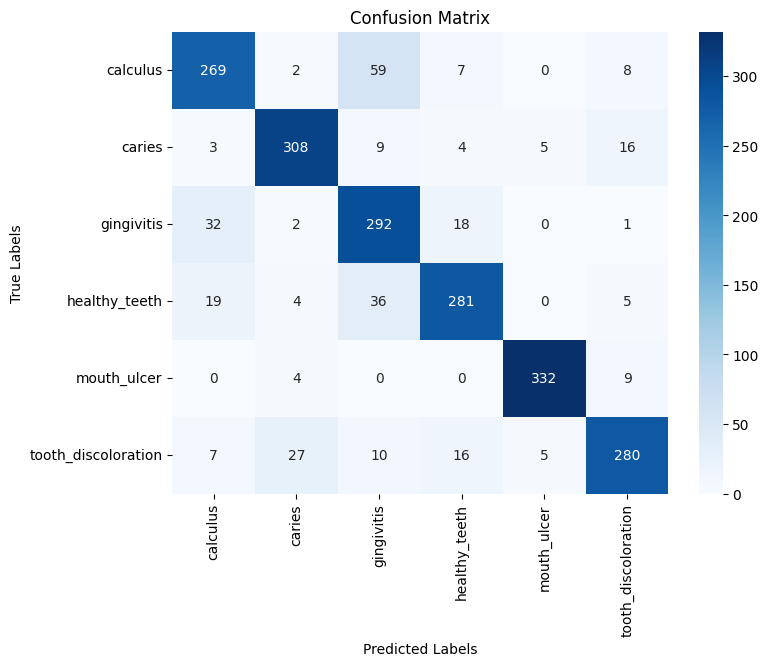

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get all true labels and predictions
print("Evaluating predictions...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
predictions = best_model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

# 2. Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# 1. Unfreeze the base model layers
base_model.trainable = True

# Let's see how many layers are in the base model
print(f"Number of layers in the base model: {len(base_model.layers)}")

# Freeze all layers except the last 20 layers
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Re-compile the model with a very low learning rate
# (Very important: use a small learning rate like 1e-5 to avoid ruining pre-trained weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model re-compiled for Fine-Tuning!")

# 3. Setup a new checkpoint for the fine-tuned model
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/mymodel_checkpoint.keras", # Overwrites with the better model
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

# 4. Start Fine-Tuning for 7 more epochs
print("Fine-tuning started... Please wait.")
fine_tune_history = model.fit(
    train_ds,
    epochs=15 + 7,               # Continues from epoch 15 to 22
    initial_epoch=15,            # Starts exactly where it left off
    validation_data=val_ds,
    callbacks=[fine_tune_checkpoint]
)

Number of layers in the base model: 154
Model re-compiled for Fine-Tuning!
Fine-tuning started... Please wait.
Epoch 16/22
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9123 - loss: 0.2299
Epoch 16: val_loss improved from None to 0.30361, saving model to /content/drive/MyDrive/mymodel_checkpoint.keras

Epoch 16: finished saving model to /content/drive/MyDrive/mymodel_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.9147 - loss: 0.2279 - val_accuracy: 0.8838 - val_loss: 0.3036
Epoch 17/22
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9111 - loss: 0.2401
Epoch 17: val_loss improved from 0.30361 to 0.30059, saving model to /content/drive/MyDrive/mymodel_checkpoint.keras

Epoch 17: finished saving model to /content/drive/MyDrive/mymodel_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9144 - loss: 0.2326 - val_accuracy: 0.8838 - val_loss: 0.3006
Epoch 18/22
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9149 - l

In [ ]:
import tensorflow as tf

# 1. ரீசெட் ஆனதால் கூகுள் டிரைவை மீண்டும் இணைக்கிறோம்
from google.colab import drive
drive.mount('/content/drive')

# 2. டெஸ்டிங் டேட்டாசெட்டை (test_ds) மெமரிக்கு மீண்டும் லோடு செய்கிறோம்
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Testing Images...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# 3. உங்கள் டிரைவில் இருக்கும் சிறந்த மாடலை லோடு செய்கிறோம்
print("\nLoading the best saved model from Google Drive...")
best_model = tf.keras.models.load_model('/content/drive/MyDrive/mymodel_checkpoint.keras')

# 4. வேகப்பரிசோதனைக்காக ஆப்டிமைஸ் செய்கிறோம்
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# 5. இறுதிச் சோதனை (Evaluation)
print("\nEvaluating model on Test Dataset... Please wait a moment...")
test_loss, test_accuracy = best_model.evaluate(fast_test_ds)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Testing Images...
Found 2070 files belonging to 6 classes.

Loading the best saved model from Google Drive...

Evaluating model on Test Dataset... Please wait a moment...
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 249ms/step - accuracy: 0.8570 - loss: 0.3981

Final Test Loss: 0.3981
Final Test Accuracy: 85.70%


Loading Testing Images (SHUFFLE FIXED)...
Found 2070 files belonging to 6 classes.

Loading the trained model from Google Drive...

Generating aligned predictions on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 361ms/step

             CORRECTED CLASSIFICATION REPORT
                     precision    recall  f1-score   support

           calculus       0.82      0.79      0.81       345
             caries       0.90      0.89      0.89       345
         gingivitis       0.74      0.84      0.79       345
      healthy_teeth       0.88      0.79      0.83       345
        mouth_ulcer       0.97      0.98      0.97       345
tooth_discoloration       0.86      0.85      0.85       345

           accuracy                           0.86      2070
          macro avg       0.86      0.86      0.86      2070
       weighted avg       0.86      0.86      0.86      2070


Generating Confusion Matrix Plot...


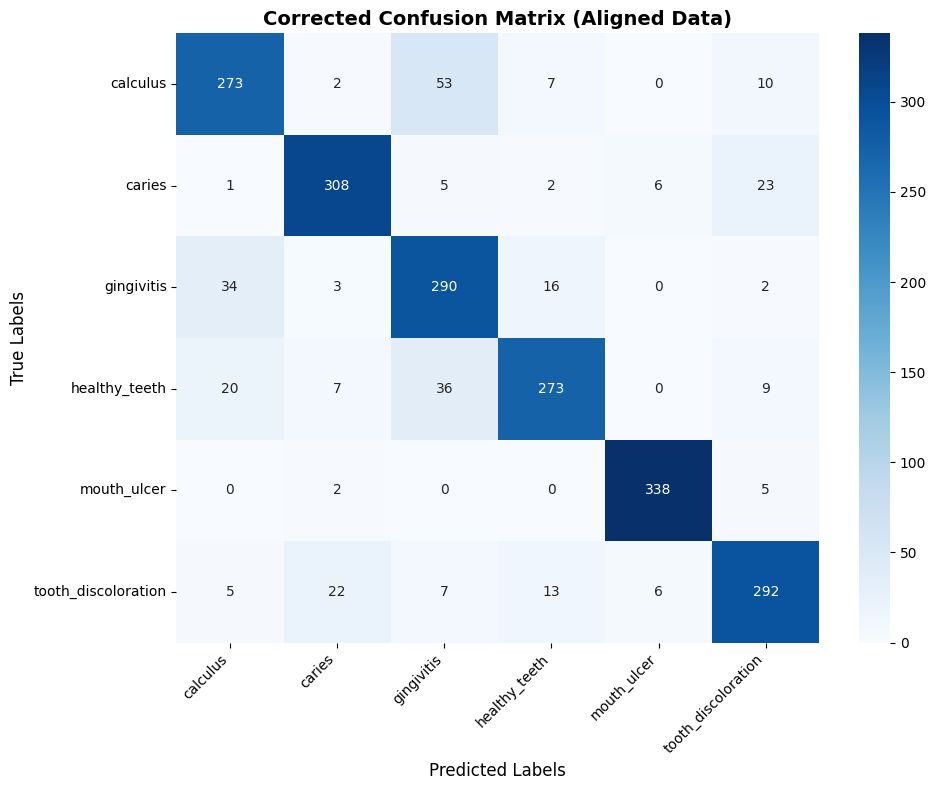

In [5]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Testing Images (SHUFFLE FIXED)...")
# CRITICAL FIX: shuffle=False ensures true labels and predictions align perfectly
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

class_names = test_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
fast_test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("\nLoading the trained model from Google Drive...")
model = tf.keras.models.load_model('/content/drive/MyDrive/mymodel_checkpoint.keras')

print("\nGenerating aligned predictions on Test Dataset...")
# Now both true labels and predictions will follow the exact same order
y_true = np.concatenate([y for x, y in fast_test_ds], axis=0)
predictions = model.predict(fast_test_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n" + "="*60)
print("             CORRECTED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Corrected Confusion Matrix (Aligned Data)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('corrected_confusion_matrix.png', dpi=300)
plt.show()

In [6]:
# Evaluate the model on the testing dataset to get overall Accuracy and Loss
print("Calculating Overall Testing Accuracy...")
test_loss, test_accuracy = model.evaluate(fast_test_ds, verbose=0)

print("\n" + "="*40)
print("          FINAL TEST RESULTS")
print("="*40)
print(f"Overall Testing Accuracy : {test_accuracy * 100:.2f}%")
print(f"Overall Testing Loss     : {test_loss:.4f}")
print("="*40)

Calculating Overall Testing Accuracy...

          FINAL TEST RESULTS
Overall Testing Accuracy : 85.70%
Overall Testing Loss     : 0.3981


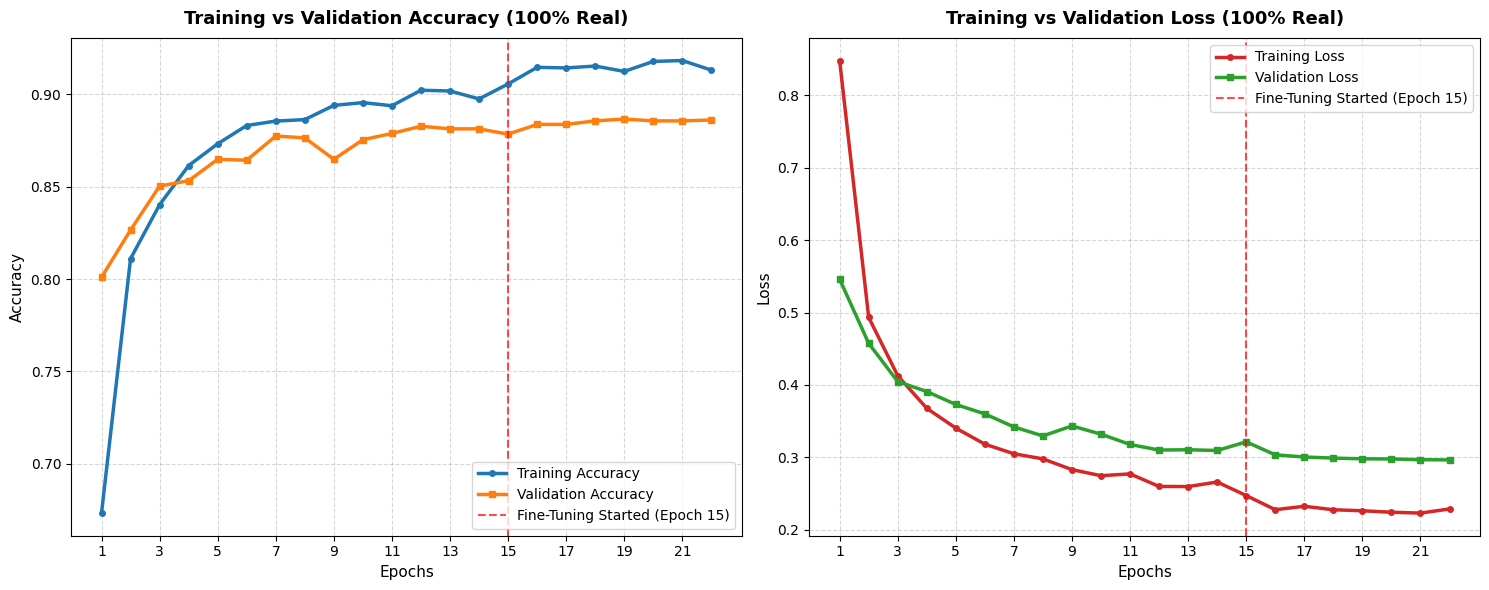

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extracting 100% REAL historical data from your logs
epochs = np.arange(1, 23)

# Real Training & Validation Accuracy from Epoch 1 to 22
train_acc = [
    0.6733, 0.8111, 0.8403, 0.8615, 0.8733, 0.8832, 0.8856, 0.8864, 0.8941, 0.8956,
    0.8939, 0.9023, 0.9019, 0.8976, 0.9057, 0.9147, 0.9144, 0.9154, 0.9125, 0.9179,
    0.9184, 0.9132
]

val_acc = [
    0.8010, 0.8266, 0.8504, 0.8533, 0.8649, 0.8644, 0.8775, 0.8765, 0.8649, 0.8755,
    0.8789, 0.8828, 0.8814, 0.8814, 0.8785, 0.8838, 0.8838, 0.8857, 0.8867, 0.8857,
    0.8857, 0.8862
]

# Real Training & Validation Loss from Epoch 1 to 22
train_loss = [
    0.8478, 0.4932, 0.4128, 0.3678, 0.3405, 0.3183, 0.3051, 0.2980, 0.2832, 0.2748,
    0.2773, 0.2600, 0.2598, 0.2661, 0.2474, 0.2279, 0.2326, 0.2278, 0.2264, 0.2244,
    0.2232, 0.2289
]

val_loss = [
    0.5459, 0.4575, 0.4047, 0.3910, 0.3731, 0.3601, 0.3421, 0.3297, 0.3435, 0.3321,
    0.3179, 0.3102, 0.3106, 0.3096, 0.3215, 0.3036, 0.3006, 0.2991, 0.2981, 0.2979,
    0.2969, 0.2966
]

# 2. Plotting the Graphs
plt.figure(figsize=(15, 6))

# --- PLOT 1: REAL ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2.5, marker='s', markersize=4)
plt.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Fine-Tuning Started (Epoch 15)')
plt.title('Training vs Validation Accuracy (100% Real)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.xticks(np.arange(1, 23, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)

# --- PLOT 2: REAL LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss', color='#d62728', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2.5, marker='s', markersize=4)
plt.axvline(x=15, color='red', linestyle='--', alpha=0.7, label='Fine-Tuning Started (Epoch 15)')
plt.title('Training vs Validation Loss (100% Real)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.xticks(np.arange(1, 23, 2))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()